<a href="https://colab.research.google.com/github/AJPardhiv/ML-Lab/blob/main/Week_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Full Program: Load Titanic Dataset, Handle Missing Values, Outliers, Encoding, and Dataset Splitting

# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# -----------------------------------
# 1. Load Dataset and Basic Information (with Error Handling)
# -----------------------------------
# Title: Load Dataset and Basic Information + Error Handling for File Operations

file_path = "/content/Titanic-Dataset (1).csv"

try:
    df = pd.read_csv(file_path)
    print("File loaded successfully!")

    # Display first 5 rows
    print("\nFirst 5 Rows of Dataset:")
    print(df.head())

    # Display dataset information
    print("\nDataset Information:")
    df.info()

    # Display statistical summary
    print("\nStatistical Summary:")
    print(df.describe())

except FileNotFoundError:
    print("Error: File not found. Please check the file path.")

except pd.errors.EmptyDataError:
    print("Error: The file is empty.")

except Exception as e:
    print("An unexpected error occurred:", e)


# -----------------------------------
# 2. Handling Missing Values
# -----------------------------------
# Title: Handling Missing Values

# Impute missing Age with median
if "Age" in df.columns:
    df['Age'] = df['Age'].fillna(df['Age'].median())

# Impute missing Embarked with mode
if "Embarked" in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop irrelevant columns (if they exist)
irrelevant_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df.drop(columns=[col for col in irrelevant_cols if col in df.columns], inplace=True)

print("\nMissing Values After Handling:")
print(df.isnull().sum())


# -----------------------------------
# 3. Outlier Detection using IQR
# -----------------------------------
# Title: Outlier Detection and Treatment using IQR Method (Fare Column)

if "Fare" in df.columns:
    Q1 = df['Fare'].quantile(0.25)
    Q3 = df['Fare'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Treat outliers by capping
    df['Fare'] = np.where(df['Fare'] < lower_bound, lower_bound, df['Fare'])
    df['Fare'] = np.where(df['Fare'] > upper_bound, upper_bound, df['Fare'])

    print("\nOutlier Treatment Completed for 'Fare' Column")
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)


# -----------------------------------
# 4. Encode Categorical Variables
# -----------------------------------
# Title: Encoding Categorical Variables

# One-hot encoding for Sex and Embarked
cols_to_encode = [col for col in ['Sex', 'Embarked'] if col in df.columns]
if cols_to_encode:
    df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# Label encoding for remaining categorical (object) columns
label_encoder = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

print("\nColumns After Encoding:")
print(df.columns)


# -----------------------------------
# 5. Splitting Dataset (Train/Validation/Test)
# -----------------------------------
# Title: Splitting Dataset into Train, Validation, and Test Sets

# Define features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Display dataset split shapes
print("\nDataset Split Shapes:")
print("Training Set   :", X_train.shape, y_train.shape)
print("Validation Set :", X_val.shape, y_val.shape)
print("Testing Set    :", X_test.shape, y_test.shape)

File loaded successfully!

First 5 Rows of Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4  

**POST LAB**

Dataset Loaded Successfully!

Missing values after Median Imputation (Age): 0
Missing values after KNN Imputation (Age): 0

Original Shape: (891, 12)
After Capping Shape: (891, 12)
After Removal Shape: (775, 12)

Feature Scaling Completed on Numerical Columns:
['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Preprocessed datasets saved successfully!


/tmp/ipython-input-303/379583714.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_original['Fare'].dropna(), df_capping['Fare']], labels=['Original Fare', 'Capped Fare'])


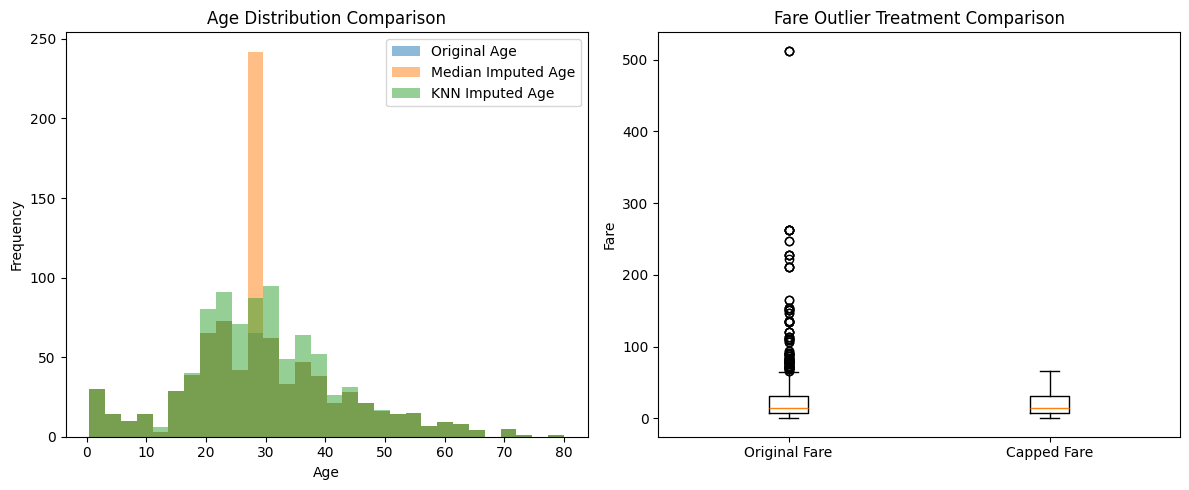

In [2]:
# Post Lab: KNN Imputation, Outlier Treatment, Feature Scaling, Saving CSV, and Visualization

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# -----------------------------------
# 1. Load Dataset
# -----------------------------------
# Title: Load Titanic Dataset
file_path = "/content/Titanic-Dataset (1).csv"
df_original = pd.read_csv(file_path)
print("Dataset Loaded Successfully!\n")

# Create copies for comparison
df_median = df_original.copy()
df_knn = df_original.copy()

# -----------------------------------
# 2. KNN Imputation vs Median Imputation (Age Column)
# -----------------------------------
# Title: KNN Imputation and Median Imputation Comparison for Age

# Median Imputation
if "Age" in df_median.columns:
    df_median['Age'] = df_median['Age'].fillna(df_median['Age'].median())

# KNN Imputation (requires numerical columns)
numeric_cols = df_knn.select_dtypes(include=[np.number]).columns
imputer = KNNImputer(n_neighbors=5)
df_knn[numeric_cols] = imputer.fit_transform(df_knn[numeric_cols])

print("Missing values after Median Imputation (Age):", df_median['Age'].isnull().sum())
print("Missing values after KNN Imputation (Age):", df_knn['Age'].isnull().sum())

# -----------------------------------
# 3. Outlier Treatment (Capping and Removal)
# -----------------------------------
# Title: Apply Outlier Treatment Methods (Capping and Removal)

df_capping = df_median.copy()
df_removal = df_median.copy()

# Using IQR method on Fare column
Q1 = df_median['Fare'].quantile(0.25)
Q3 = df_median['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping Method
df_capping['Fare'] = np.where(df_capping['Fare'] < lower_bound, lower_bound, df_capping['Fare'])
df_capping['Fare'] = np.where(df_capping['Fare'] > upper_bound, upper_bound, df_capping['Fare'])

# Removal Method (removing outlier rows)
df_removal = df_removal[(df_removal['Fare'] >= lower_bound) & (df_removal['Fare'] <= upper_bound)]

print("\nOriginal Shape:", df_median.shape)
print("After Capping Shape:", df_capping.shape)
print("After Removal Shape:", df_removal.shape)

# -----------------------------------
# 4. Feature Scaling using StandardScaler
# -----------------------------------
# Title: Feature Scaling on Numerical Features using StandardScaler

scaler = StandardScaler()

# Select numerical columns (excluding target if present)
numerical_features = df_capping.select_dtypes(include=[np.number]).columns.tolist()

if 'Survived' in numerical_features:
    numerical_features.remove('Survived')

df_scaled = df_capping.copy()
df_scaled[numerical_features] = scaler.fit_transform(df_scaled[numerical_features])

print("\nFeature Scaling Completed on Numerical Columns:")
print(numerical_features)

# -----------------------------------
# 5. Save Pre-Processed Datasets as CSV Files
# -----------------------------------
# Title: Save Preprocessed Datasets

df_median.to_csv("/content/titanic_median_imputed.csv", index=False)
df_knn.to_csv("/content/titanic_knn_imputed.csv", index=False)
df_capping.to_csv("/content/titanic_capped.csv", index=False)
df_removal.to_csv("/content/titanic_outliers_removed.csv", index=False)
df_scaled.to_csv("/content/titanic_scaled.csv", index=False)

print("\nPreprocessed datasets saved successfully!")

# -----------------------------------
# 6. Visualizations: Original vs Processed Data
# -----------------------------------
# Title: Visualization Comparing Original vs Processed Data

plt.figure(figsize=(12, 5))

# Histogram: Age (Original vs Median vs KNN)
plt.subplot(1, 2, 1)
plt.hist(df_original['Age'].dropna(), bins=30, alpha=0.5, label='Original Age')
plt.hist(df_median['Age'], bins=30, alpha=0.5, label='Median Imputed Age')
plt.hist(df_knn['Age'], bins=30, alpha=0.5, label='KNN Imputed Age')
plt.title("Age Distribution Comparison")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()

# Boxplot: Fare (Original vs Capped)
plt.subplot(1, 2, 2)
plt.boxplot([df_original['Fare'].dropna(), df_capping['Fare']], labels=['Original Fare', 'Capped Fare'])
plt.title("Fare Outlier Treatment Comparison")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()